
# Short Introduction to Metabolomics


---


# Hands-On: Correlation Analysis Between Metabolites and Microbes

In this exercise, we will use a small example dataset from the PROTECT cohort. This stands for Predicting Response to Standardized Colitis Therapy (PROTECT) and is a pediatric inception cohort. The age of the UC patients ranges from 4 to 17. [Here](https://www.sciencedirect.com/science/article/pii/S1931312823005085#sec5) you can find the paper to the cohort.

We are looking at the microbial abundances on species level and metabolite abundances, both in stool samples. 

You should do the following steps using R. In the process, or after you have finished the tasks, please answer the following questions.

1. Load metabolite and microbial abundance data
2. Preprocess the data (e.g., normalization, filtering, transformation)
3. Calculate Spearman correlations
4. Visualize significant correlations in a heatmap

Here are also links to more information about [Spearman correlation in general](https://www.statstutor.ac.uk/resources/uploaded/spearmans.pdf) and [calculation in R](https://www.geeksforgeeks.org/r-language/spearman-correlation-testing-in-r-programming/).


### Questions
- Look at the example data: what can you tell about the measurement? What measurement modes or methods were used? (See Supplementary Table S4 in the paper linked above)
- Why is transformation important in this data analysis? What methods are used here?
- Which metabolite shows the strongest overall correlation with which microbe?
- How would you interpret the correlation coefficients for our data? Are they high? Are they low?

**⚠️ Kernel:** Click **Select Kernel** (top right) → **Jupyter Kernel...** → **R (conda)**

In [1]:
# Load required libraries
library(tidyverse)
library(reshape2)
library(ggplot2)
library(compositions)
library(psych)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.2
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘reshape2’


The following object is masked from ‘package:tidyr’:

    smiths


Welcome to compositions, a package for compositional data analysis.
Find an intro with "? compositions"



Attaching package: ‘compositions’


The following objects are masked from ‘package:stats’:

    anova, cor, cov, dist, var


The following object is masked from ‘package:graphics’:

    segments


The following objects are masked from ‘package:base’:

    %*%, norm, sc

In [ ]:
BASE_PATH <- "/biodata/resources/MBX_intro"

In [ ]:
# Read in Species abundance table 
df_sp <- read.csv(file.path(BASE_PATH, "protect_species_abundance.csv"), sep=";", header = TRUE)
# Delete rows that have <10% of non-zero values
df_sp <- df_sp[rowSums(df_sp != 0) >= 0.3 * ncol(df_sp), ]

df_met <- read.csv(file.path(BASE_PATH, "protect_stool_metabolite_abundance.csv"), sep=";", header = TRUE)

# Extract rows 1-178 (limiting dataset to HILIC positive, annotated metabolites)
df_met <- df_met[1:178, 1:(ncol(df_met)-2)]

# Delete columns from df_sp that are not in columns from df_met
df_sp <- df_sp[, colnames(df_sp) %in% colnames(df_met)]

# Transpose dataframes
rownames(df_sp) <- df_sp[,1]
df_sp_t <- as.data.frame(t(df_sp[,-1]))
rownames(df_met) <- df_met[,1]
df_met_t <- as.data.frame(t(df_met[,-1]))

# Convert metabolite columns to numeric (handle potential character columns)
df_met_t <- df_met_t %>%
  mutate_all(~ as.numeric(as.character(.)))

# Only keep top 10 abundant metabolites by median
median_abundance <- apply(df_met_t, 2, median, na.rm = TRUE)
top10_metabolites <- names(sort(median_abundance, decreasing = TRUE)[1:10])
df_met_t <- df_met_t[, top10_metabolites]

# Sort rows alphabetically by row names
df_sp_t <- df_sp_t[order(rownames(df_sp_t)), ]
df_met_t <- df_met_t[order(rownames(df_met_t)), ]

head(df_sp_t)
head(df_met_t)

Warning message:
“There were 3 warnings in `mutate()`.
The first warning was:
ℹ In argument: `HPs_QI15038_6 = (structure(function (..., .x = ..1, .y = ..2, .
  = ..1) ...`.
Caused by warning in `as.numeric()`:
! NAs introduced by coercion
ℹ Run `dplyr::last_dplyr_warnings()` to see the 2 remaining warnings.”


,Bifidobacterium_adolescentis,Bifidobacterium_bifidum,Bifidobacterium_longum,Bifidobacterium_pseudocatenulatum,Collinsella_aerofaciens,Eggerthella_lenta,Eggerthella_unclassified,Gordonibacter_pamelaeae,Bacteroides_caccae,Bacteroides_dorei,⋯,Holdemania_filiformis,Dialister_invisus,Veillonella_atypica,Veillonella_dispar,Veillonella_parvula,Veillonella_unclassified,Bilophila_unclassified,Escherichia_coli,Escherichia_unclassified,Haemophilus_parainfluenzae
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
STL10022,0.0011044,0.0001859,0.0108857,0.0000000,0.0000000,0.0002786,0.0031752,0.0000000,0.000000,0.0000000,⋯,0,0.1216334,0.0206022,0.0012946,0.0007044,0.0307310,0.0031353,0.0958019,0.0000000,0.0186155
STL10037,0.0000579,0.0000000,0.0001335,0.0000000,0.1191570,0.0006963,0.0074486,0.0000000,0.000000,0.0000000,⋯,0,0.0004741,0.0012712,0.0012897,0.0004561,0.0000000,0.0000000,0.1564987,0.0004066,0.0002166
STL10126,0.0000000,0.0000000,0.0111126,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,0.000000,0.0916889,⋯,0,0.0000000,0.0000000,0.0005044,0.0607084,0.0192814,0.0000000,0.3089663,0.0000000,0.0006384
STL10177,0.2427113,0.1424402,0.3564692,0.0296470,0.0000000,0.0000812,0.0017180,0.0000000,0.001834,0.0073668,⋯,0,0.0052791,0.0002749,0.0000000,0.0000586,0.0004905,0.0000000,0.0018551,0.0000000,0.0003602
STL10180,0.3326943,0.0000000,0.1762686,0.0095436,0.2300416,0.0002264,0.0046744,0.0005524,0.000000,0.0079402,⋯,0,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000
STL10191,0.0010482,0.0000000,0.0001605,0.0000000,0.0084047,0.0000000,0.0005996,0.0000000,0.000000,0.0000000,⋯,0,0.0032809,0.0000685,0.0000000,0.0003061,0.0013193,0.0000000,0.0291497,0.0060716,0.0106974


,HPs_TF12_leucine,HPs_TF17_phenylalanine,HPs_TF25_valine,HPs_TF11_isoleucine,HPs_TF10_imidazole propionate,HPs_TF24_tyrosine,HPs_TF23_tryptophan,HPs_TF9_guanine,HPs_TF5_ADMA,HPs_TF21_SDMA
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
STL10022,632164330,773057100,513440780,234551737,284699652,134196262,114687165,34623693,9061739,8079942
STL10037,1510760975,1746019290,779590477,562345600,41125204,352515964,305000473,822786674,87950807,11426659
STL10126,1152968656,1246677746,679395245,564611654,389010485,337217945,138649449,36372293,118490817,13826749
STL10177,216815206,208347251,394925300,101725400,75323422,52203460,49000447,135326636,19965684,9910014
STL10180,349315297,354336795,292961451,272707821,291894973,89742526,63973174,15419948,1469559,584880
STL10191,51992077,68200239,200199429,29976847,101850485,14766983,10572618,38523431,13048016,7191738


In [3]:
# DATA TRANSFORMATION

# Introduce pseudocount 
min_val <- min(df_sp_t[df_sp_t > 0], na.rm = TRUE)
df_sp_t[is.na(df_sp_t)] <- min_val / 2

min_val <- min(df_met_t[df_met_t > 0], na.rm = TRUE)
df_met_t[is.na(df_met_t)] <- min_val / 2

# Apply CLR transformation to species
df_sp_clr <- as.data.frame(t(apply(df_sp_t, 1, function(x) clr(x))))

# Normalise metabolite intensities using TIC (Total Ion Current) method
# Calculate total ion current for each sample (row sums)
tic_sums <- rowSums(df_met_t, na.rm = TRUE)
# Apply TIC normalization: divide each intensity by sample total
df_met_tic <- df_met_t / tic_sums

# Apply LOG2 transformation to metabolites
df_met_log <- as.data.frame(t(apply(df_met_tic, 1, function(x) log2(x))))


In [4]:
# Combine the transformed data
combined_data <- cbind(df_met_log, df_sp_clr)

# Compute Spearman correlation and adjust p-values using Benjamini-Hochberg
cor_results <- corr.test(combined_data, method = "spearman", adjust = "BH")

# Correlation coefficients
cor_matrix <- cor_results$r

# Adjusted p-values
p_matrix <- cor_results$p


# Get column names
metabolite_names <- colnames(df_met_log)
microbe_names <- colnames(df_sp_clr)

# Subset correlation and p-value matrices
cor_subset <- cor_matrix[metabolite_names, microbe_names]
p_subset <- p_matrix[metabolite_names, microbe_names]


In [5]:
# Define significance threshold
sig_threshold <- 0.1 

# Create mask for significant correlations
sig_mask <- p_subset < sig_threshold

# Extract significant correlations
sig_correlations <- cor_subset[sig_mask]


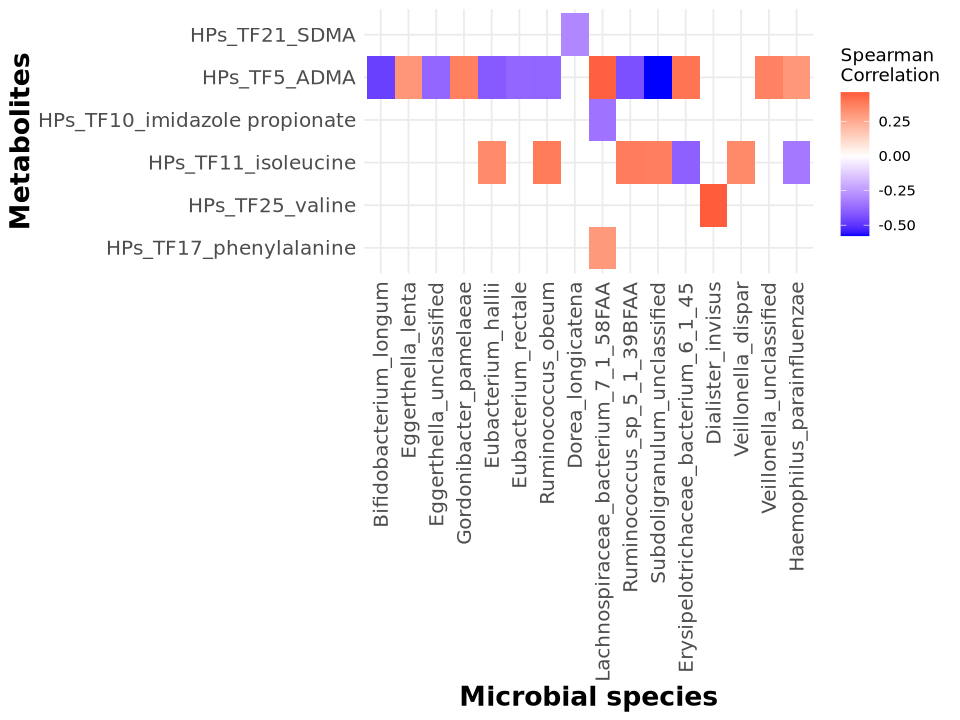

In [6]:
# Mask insignificant correlations
cor_filtered <- cor_subset
cor_filtered[p_subset >= sig_threshold] <- NA  # Set non-significant to NA

# Melt and plot
cor_melted <- melt(cor_filtered, na.rm = TRUE)

# Adjust figsize
options(repr.plot.width = 8, repr.plot.height = 6)

# Plot
ggplot(cor_melted, aes(x = Var2, y = Var1, fill = value)) +
  geom_tile() +
  scale_fill_gradient2(low = "blue", high = "red", mid = "white",
                       midpoint = 0, limit = c(min(cor_melted$value, na.rm = TRUE), max(cor_melted$value, na.rm = TRUE)), space = "Lab",
                       name="Spearman\nCorrelation") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1, size = 12),
        axis.text.y = element_text(size = 12),
        axis.title.x = element_text(size = 16, face = "bold"),
        axis.title.y = element_text(size = 16, face = "bold")
        ) +
  labs(x = "Microbial species", y = "Metabolites", fontsize = 16)
